In [108]:
#import sys
#from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as tic
%matplotlib inline
mpl.rc('text',usetex=True)
mpl.rc('font',size=20)

In [146]:
# Load data
cols = [0,3]+[i for i in range(5,21)]
datasets = []
data = np.genfromtxt("datafiles/res_wavefunction_eta1.00_lmdR0.00.txt",usecols=cols)
data2 = np.genfromtxt("datafiles/res_wavefunction_eta0.50_lmdR0.00.txt",usecols=cols)
data3 = np.genfromtxt("datafiles/res_wavefunction_eta0.25_lmdR0.00.txt",usecols=cols)
data4 = np.genfromtxt("datafiles/res_wavefunction_eta0.25_lmdR0.84.txt",usecols=cols)
data5 = np.genfromtxt("datafiles/res_wavefunction_eta0.60_lmdR0.84.txt",usecols=cols)
data6 = np.genfromtxt("datafiles/res_wavefunction_eta0.60_lmdR0.36.txt",usecols=cols)


#data2 = np.genfromtxt("datafiles/res_wavefunction_eta0.75_lambdaR0.0.txt",usecols=cols)
#data3 = np.genfromtxt("datafiles/res_wavefunction_eta0.50_lambdaR0.0.txt",usecols=cols)
#data4 = np.genfromtxt("datafiles/res_wavefunction_eta0.25_lambdaR0.0.txt",usecols=cols) 

In [15]:
print(data.shape)

(200, 18)


In [61]:
# compute |psi|^2
N = len(data[:,0])
M = int(N/2)
num_states = 8
psi = np.zeros((M,2+num_states)) 
for i in range(0,M):
    row = 2*i
    psi[i,0] = i
    psi[i,1] = data[row,1]
    for m in range(num_states):
        # up-spin psi-s
        col = 2+2*m
        re_up, im_up = data[row,col], data[row,col+1]
        re_dn, im_dn = data[row+1,col], data[row+1,col+1]
        psi_sq = (re_up*re_up+im_up*im_up) + (re_dn*re_dn+im_dn*im_dn)
        psi[i,2+m] = psi_sq
psi[-1,0] = M

In [78]:
def get_wf(data):
    N = len(data[:,0])
    M = int(N/2)
    num_states = 8
    psi = np.zeros((M,2+num_states)) 
    for i in range(0,M):
        row = 2*i
        psi[i,0] = i
        psi[i,1] = data[row,1]
        for m in range(num_states):
            # up-spin psi-s
            col = 2+2*m
            re_up, im_up = data[row,col], data[row,col+1]
            re_dn, im_dn = data[row+1,col], data[row+1,col+1]
            psi_sq = (re_up*re_up+im_up*im_up) + (re_dn*re_dn+im_dn*im_dn)
            psi[i,2+m] = psi_sq
    psi[-1,0] = M
    return psi

In [56]:
a = np.sqrt(3)

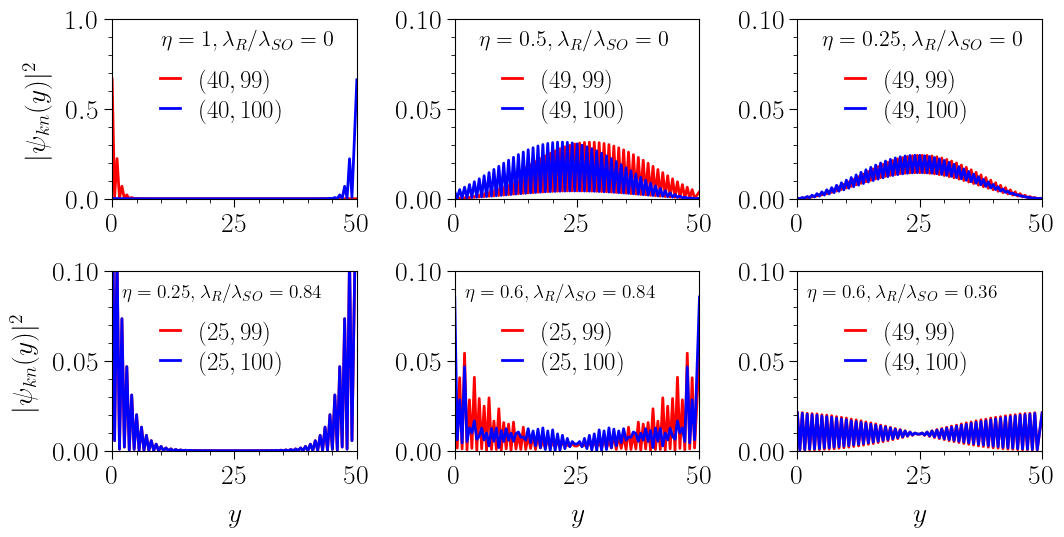

In [172]:
fig = plt.figure(figsize=(12,6))
#---------------------------------------------------------------------
ax1 = fig.add_subplot(231)
psi = get_wf(data)
ax1.plot(psi[:,0]/2,psi[:,3],label=r'$(40,99)$',ls='-',marker='',c='r',lw=2)
ax1.plot(psi[:,0]/2,psi[:,4],label=r'$(40,100)$',ls='-',marker='',c='b',lw=2)
ax1.legend(title='',fontsize=18,frameon=False,labelspacing=0.2,handlelength=0.8,loc='upper right',bbox_to_anchor=(0.80,0.85))
ax1.text(0.2,0.85,s=r'$\eta=1,\lambda_R/\lambda_{SO}=0$',transform=ax1.transAxes,size=16)
#ax1.set_xlabel(r'$y$',labelpad=10,fontsize=35)
ax1.set_ylabel(r'$|\psi_{kn}(y)|^{2}$',labelpad=10,fontsize=20)
ax1.set_xlim(0,50)
ax1.xaxis.set_major_locator(tic.MultipleLocator(25))
ax1.xaxis.set_minor_locator(tic.MultipleLocator(5))
ax1.set_ylim(0.0,1.0)
ax1.yaxis.set_major_locator(tic.MultipleLocator(0.5))
ax1.yaxis.set_minor_locator(tic.MultipleLocator(0.1))
ax1.tick_params(length=6)
ax1.tick_params(which='minor',length=3)
#----------------------------------------------------------------------
ax2 = fig.add_subplot(232)
psi = get_wf(data2)
ax2.plot(psi[:,0]/2,psi[:,3],label=r'$(49,99)$',ls='-',marker='',c='r',lw=2)
ax2.plot(psi[:,0]/2,psi[:,5],label=r'$(49,100)$',ls='-',marker='',c='b',lw=2)
ax2.legend(title='',fontsize=18,frameon=False,labelspacing=0.2,handlelength=0.8,loc='upper right',bbox_to_anchor=(0.80,0.85))
ax2.text(0.1,0.85,s=r'$\eta=0.5,\lambda_R/\lambda_{SO}=0$',transform=ax2.transAxes,size=16)
#ax1.set_xlabel(r'$y$',labelpad=10,fontsize=35)
#ax2.set_ylabel(r'$|\psi_{kn}(y)|^{2}$',labelpad=10,fontsize=20)
ax2.set_xlim(0,50)
ax2.xaxis.set_major_locator(tic.MultipleLocator(25))
ax2.xaxis.set_minor_locator(tic.MultipleLocator(5))
ax2.set_ylim(0.0,0.1)
ax2.yaxis.set_major_locator(tic.MultipleLocator(0.05))
ax2.yaxis.set_minor_locator(tic.MultipleLocator(0.01))
ax2.tick_params(length=6)
ax2.tick_params(which='minor',length=3)
#----------------------------------------------------------------------
ax3 = fig.add_subplot(233)
psi = get_wf(data3)
ax3.plot(psi[:,0]/2,psi[:,3],label=r'$(49,99)$',ls='-',marker='',c='r',lw=2)
ax3.plot(psi[:,0]/2,psi[:,5],label=r'$(49,100)$',ls='-',marker='',c='b',lw=2)
ax3.legend(title='',fontsize=18,frameon=False,labelspacing=0.2,handlelength=0.8,loc='upper right',bbox_to_anchor=(0.80,0.85))
ax3.text(0.1,0.85,s=r'$\eta=0.25,\lambda_R/\lambda_{SO}=0$',transform=ax3.transAxes,size=16)
#ax1.set_xlabel(r'$y$',labelpad=10,fontsize=35)
#ax2.set_ylabel(r'$|\psi_{kn}(y)|^{2}$',labelpad=10,fontsize=20)
ax3.set_xlim(0,50)
ax3.xaxis.set_major_locator(tic.MultipleLocator(25))
ax3.xaxis.set_minor_locator(tic.MultipleLocator(5))
ax3.set_ylim(0.0,0.1)
ax3.yaxis.set_major_locator(tic.MultipleLocator(0.05))
ax3.yaxis.set_minor_locator(tic.MultipleLocator(0.01))
ax3.tick_params(length=6)
ax3.tick_params(which='minor',length=3)
#----------------------------------------------------------------------
#----------------------------------------------------------------------
ax4 = fig.add_subplot(234)
psi = get_wf(data4)
ax4.plot(psi[:,0]/2,psi[:,3],label=r'$(25,99)$',ls='-',marker='',c='r',lw=2)
ax4.plot(psi[:,0]/2,psi[:,4],label=r'$(25,100)$',ls='-',marker='',c='b',lw=2)
ax4.legend(title='',fontsize=18,frameon=False,labelspacing=0.2,handlelength=0.8,loc='upper right',bbox_to_anchor=(0.80,0.85))
ax4.text(0.04,0.85,s=r'$\eta=0.25,\lambda_R/\lambda_{SO}=0.84$',transform=ax4.transAxes,size=14)
ax4.set_xlabel(r'$y$',labelpad=10,fontsize=20)
ax4.set_ylabel(r'$|\psi_{kn}(y)|^{2}$',labelpad=10,fontsize=20)
ax4.set_xlim(0,50)
ax4.xaxis.set_major_locator(tic.MultipleLocator(25))
ax4.xaxis.set_minor_locator(tic.MultipleLocator(5))
ax4.set_ylim(0.0,0.1)
ax4.yaxis.set_major_locator(tic.MultipleLocator(0.05))
ax4.yaxis.set_minor_locator(tic.MultipleLocator(0.01))
ax4.tick_params(length=6)
ax4.tick_params(which='minor',length=3)
#----------------------------------------------------------------------
ax5 = fig.add_subplot(235)
psi = get_wf(data5)
ax5.plot(psi[:,0]/2,psi[:,3],label=r'$(25,99)$',ls='-',marker='',c='r',lw=2)
ax5.plot(psi[:,0]/2,psi[:,5],label=r'$(25,100)$',ls='-',marker='',c='b',lw=2)
ax5.legend(title='',fontsize=18,frameon=False,labelspacing=0.2,handlelength=0.8,loc='upper right',bbox_to_anchor=(0.80,0.85))
ax5.text(0.04,0.85,s=r'$\eta=0.6,\lambda_R/\lambda_{SO}=0.84$',transform=ax5.transAxes,size=14)
ax5.set_xlabel(r'$y$',labelpad=10,fontsize=20)
#ax5.set_ylabel(r'$|\psi_{kn}(y)|^{2}$',labelpad=10,fontsize=20)
ax5.set_xlim(0,50)
ax5.xaxis.set_major_locator(tic.MultipleLocator(25))
ax5.xaxis.set_minor_locator(tic.MultipleLocator(5))
ax5.set_ylim(0.0,0.1)
ax5.yaxis.set_major_locator(tic.MultipleLocator(0.05))
ax5.yaxis.set_minor_locator(tic.MultipleLocator(0.01))
ax5.tick_params(length=6)
ax5.tick_params(which='minor',length=3)
#----------------------------------------------------------------------
ax6 = fig.add_subplot(236)
psi = get_wf(data6)
ax6.plot(psi[:,0]/2,psi[:,7],label=r'$(49,99)$',ls='-',marker='',c='r',lw=2)
ax6.plot(psi[:,0]/2,psi[:,8],label=r'$(49,100)$',ls='-',marker='',c='b',lw=2)
ax6.legend(title='',fontsize=18,frameon=False,labelspacing=0.2,handlelength=0.8,loc='upper right',bbox_to_anchor=(0.80,0.85))
ax6.text(0.04,0.85,s=r'$\eta=0.6,\lambda_R/\lambda_{SO}=0.36$',transform=ax6.transAxes,size=14)
ax6.set_xlabel(r'$y$',labelpad=10,fontsize=20)
#ax5.set_ylabel(r'$|\psi_{kn}(y)|^{2}$',labelpad=10,fontsize=20)
ax6.set_xlim(0,50)
ax6.xaxis.set_major_locator(tic.MultipleLocator(25))
ax6.xaxis.set_minor_locator(tic.MultipleLocator(5))
ax6.set_ylim(0.0,0.1)
ax6.yaxis.set_major_locator(tic.MultipleLocator(0.05))
ax6.yaxis.set_minor_locator(tic.MultipleLocator(0.01))
ax6.tick_params(length=6)
ax6.tick_params(which='minor',length=3)

# Adjust the spacing between subplots
plt.subplots_adjust(wspace=0.4, hspace=0.4)

#mpl.rc('figure.subplot',left=0.20)
mpl.rc('figure.subplot',bottom=0.16)

plt.savefig("./edgestate_wavefunctions.svg")


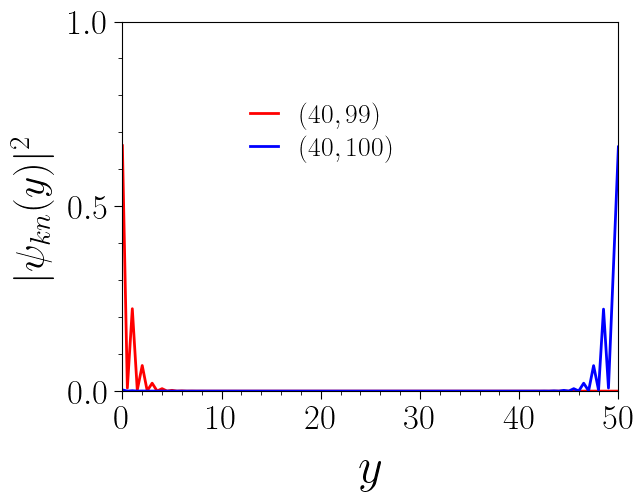

In [96]:
fig = plt.figure()
ax = fig.add_subplot(111)

psi = get_wf(data)
ax.plot(psi[:,0]/2,psi[:,3],label=r'$(40,99)$',ls='-',marker='',c='r',lw=2, ms=4)
ax.plot(psi[:,0]/2,psi[:,4],label=r'$(40,100)$',ls='-',marker='',c='b',lw=2, ms=4)

#ax.text(0.3,0.40,s=r'$p=-0.5$',transform=ax.transAxes,size=30)
ax.legend(title='',fontsize=20,frameon=False,labelspacing=0.2,handlelength=1.0,loc='upper right',bbox_to_anchor=(0.60,0.85))


ax.set_xlabel(r'$y$',labelpad=10,fontsize=35)
ax.set_ylabel(r'$|\psi_{kn}(y)|^{2}$',labelpad=10,fontsize=30)

ax.set_xlim(0,50)
ax.xaxis.set_major_locator(tic.MultipleLocator(10))
ax.xaxis.set_minor_locator(tic.MultipleLocator(2))

ax.set_ylim(0.0,1.0)
ax.yaxis.set_major_locator(tic.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(tic.MultipleLocator(0.1))
ax.tick_params(length=6)
ax.tick_params(which='minor',length=3)

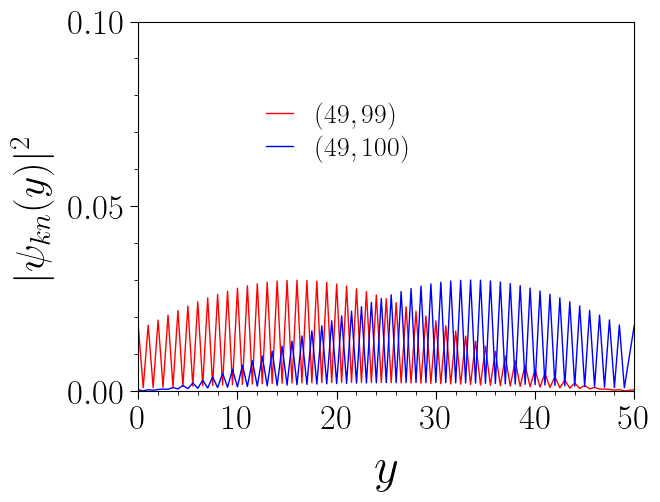

In [95]:
fig = plt.figure()
ax = fig.add_subplot(111)

psi = get_wf(data2)
ax.plot(psi[:,0]/2,psi[:,3],label=r'$(49,99)$',ls='-',marker='',c='r',lw=1, ms=4)
ax.plot(psi[:,0]/2,psi[:,5],label=r'$(49,100)$',ls='-',marker='',c='b',lw=1, ms=4)

#ax.text(0.3,0.40,s=r'$p=-0.5$',transform=ax.transAxes,size=30)
ax.legend(title='',fontsize=20,frameon=False,labelspacing=0.2,handlelength=1.0,loc='upper right',bbox_to_anchor=(0.60,0.85))


ax.set_xlabel(r'$y$',labelpad=10,fontsize=35)
ax.set_ylabel(r'$|\psi_{kn}(y)|^{2}$',labelpad=10,fontsize=30)

ax.set_xlim(0,50)
ax.xaxis.set_major_locator(tic.MultipleLocator(10))
ax.xaxis.set_minor_locator(tic.MultipleLocator(2))

ax.set_ylim(0.0,0.1)
ax.yaxis.set_major_locator(tic.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(tic.MultipleLocator(0.01))
ax.tick_params(length=6)
ax.tick_params(which='minor',length=3)